In [4]:
import torch
from matplotlib import pyplot as plt
from torchvision.utils import make_grid
from diffusion.approaches.matching.prob_paths import (
    GaussianCondProbPath,
    LinearAlpha,
    LinearBeta,
)
from diffusion.sampleables.whar_sampleable import TrainValTest, WHARSampleable
from diffusion.architectures.backbones.res_unet import ResUnet
from diffusion.approaches.matching.flow_generator import FlowGenerator, ScoreGenerator
from whar_datasets.support.getter import WHARDatasetID, get_dataset_cfg

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_dataset_cfg(WHARDatasetID.WISDM)
print(cfg.window_time)

5.0


In [6]:
sampeable = WHARSampleable(cfg=cfg, scv_group_index=0, fold=TrainValTest.TRAIN)
val_sampeable = WHARSampleable(cfg=cfg, scv_group_index=0, fold=TrainValTest.VAL)

path = GaussianCondProbPath(
    p_data=sampeable,
    p_simple_shape=sampeable.shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

backbone = ResUnet(
    in_channels=6,
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)

backbone.load_state_dict(torch.load("./models/backbone_flow_wisdm.pt"))

2025-10-16 14:26:24,197 - whar-datasets - INFO - Running DownloadingStep
2025-10-16 14:26:24,197 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-16 14:26:24,198 - whar-datasets - INFO - Hash is up to date
2025-10-16 14:26:24,198 - whar-datasets - INFO - Running ParsingStep
2025-10-16 14:26:24,199 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-16 14:26:24,199 - whar-datasets - INFO - Hash is up to date
2025-10-16 14:26:24,200 - whar-datasets - INFO - Running WindowingStep
2025-10-16 14:26:24,200 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-16 14:26:24,202 - whar-datasets - INFO - Hash is up to date
2025-10-16 14:26:24,202 - whar-datasets - INFO - Loading windowing
2025-10-16 14:26:24,212 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-16 14:26:24,213 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-16 14:26:24,215 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-16 14:26:24,216 - whar-datasets - INFO - R

<All keys matched successfully>

torch.Size([55, 6, 32, 26])


100%|██████████| 99/99 [00:04<00:00, 22.03it/s]


torch.Size([55, 6, 32, 26])
torch.Size([55, 1, 32, 26])


100%|██████████| 99/99 [00:04<00:00, 22.55it/s]


torch.Size([55, 6, 32, 26])
torch.Size([55, 1, 32, 26])


100%|██████████| 99/99 [00:04<00:00, 22.52it/s]


torch.Size([55, 6, 32, 26])
torch.Size([55, 1, 32, 26])


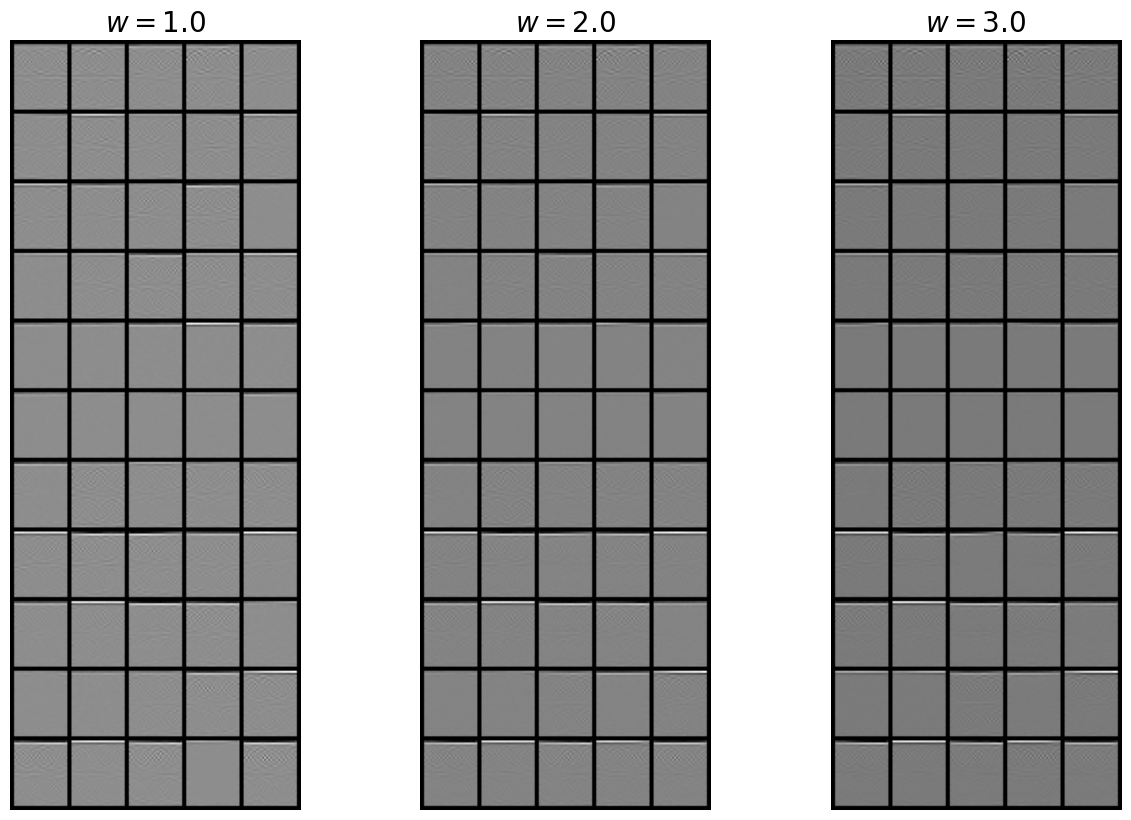

In [14]:
num_timesteps = 100
samples_per_class = 5
guidance_scales = [1.0, 2.0, 3.0]

y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .repeat_interleave(samples_per_class)
    .to(device)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(guidance_scales),
    figsize=(samples_per_class * len(guidance_scales), 10),
)

flow_generator = FlowGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x0 = flow_generator.sample_prior(
    num_samples=y.shape[0], shape=sampeable.shape, device=device, y=y
)
# (num_samples, 1, 32, 32)

print(x0.shape)

for idx, w in enumerate(guidance_scales):
    x1 = flow_generator.generate(y, x0, w)
    print(x1.shape)
    x1 = x1[:, 0:1, :, :]
    print(x1.shape)

    grid = make_grid(x1, nrow=samples_per_class, normalize=True)
    axes[idx].imshow(grid.permute(1, 2, 0).cpu())
    axes[idx].axis("off")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)

plt.show()

100%|██████████| 9/9 [00:00<00:00, 10.39it/s]


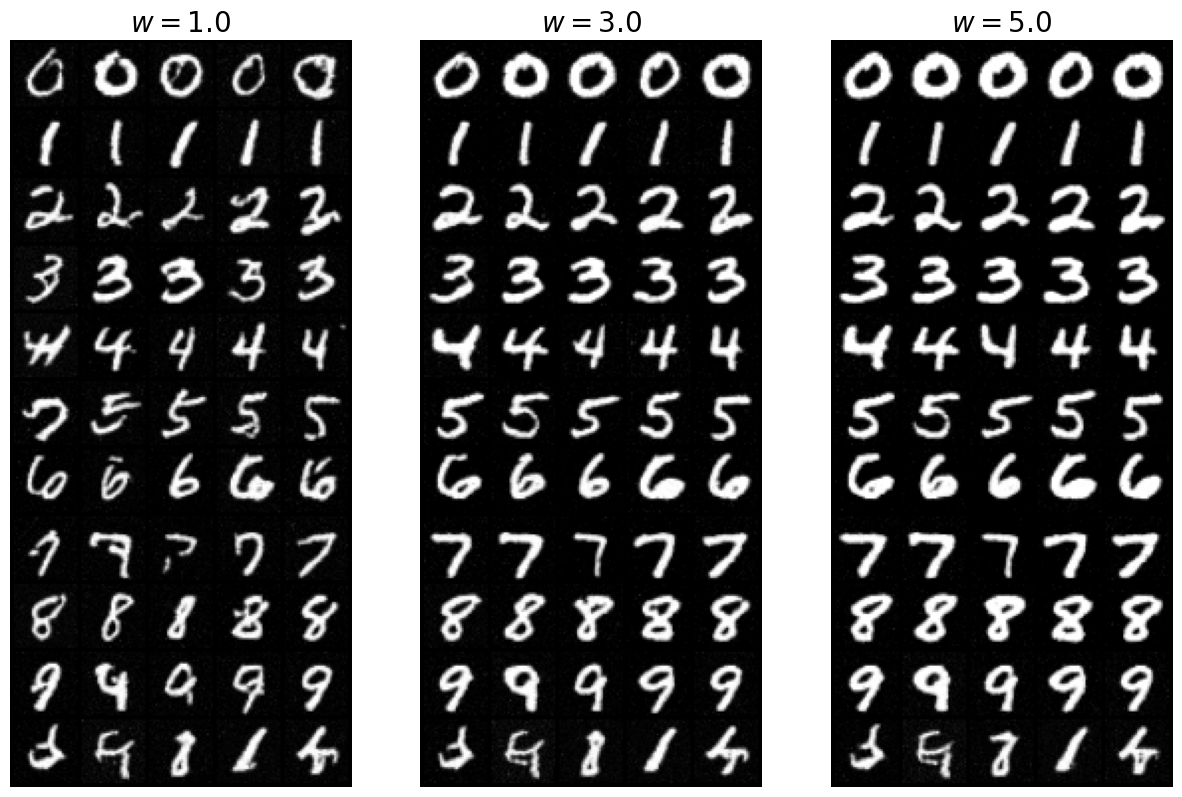

In [5]:
num_timesteps = 10
samples_per_class = 5
guidance_scales = [1.0, 3.0, 5.0]

y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .repeat_interleave(samples_per_class)
    .to(device)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(guidance_scales),
    figsize=(samples_per_class * len(guidance_scales), 10),
)

flow_generator = ScoreGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x0 = flow_generator.sample_prior(
    num_samples=y.shape[0], shape=sampeable.shape, device=device
)
# (num_samples, 1, 32, 32)

for idx, w in enumerate(guidance_scales):
    x1 = flow_generator.generate(y, x0, w)

    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1, 1))
    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)

plt.show()